# Test su frasi ambigue

## Import del modello allenato nel notebook 5

In [61]:
import joblib

model = joblib.load("../models/logistic_reg.pkl")
vectorizer = joblib.load("../models/vectorizer.pkl")
X_train_tfidf = joblib.load('../models/Xtrain.pkl')

## Creazione del dataset di frasi ambigue

In [62]:
import spacy
from spacy.tokens import DocBin, Doc

if not Doc.has_extension("post_id"):
        Doc.set_extension("post_id", default=None)

nlp = spacy.load('en_core_web_lg')
docbin = DocBin().from_disk('../data/processed/annotated_documents.spacy')
docs = list(docbin.get_docs(nlp.vocab))

In [63]:
AI_KEYWORDS = {
    "agent",
    "ai",
    "bot",
    "assistant"
}

HUMAN_KEYWORDS = {
    "human",
    "person",
    "user",
    "people"
}

ALL_KEYWORDS = AI_KEYWORDS | HUMAN_KEYWORDS


In [64]:
rows = []

closed_classes = {"ADP", "AUX", "CCONJ", "SCONJ", "DET", "NUM", "PRON", "PART"}

for doc in docs:
    for sent in doc.sents:

        subjects = [
            tok for tok in sent
            if tok.dep_ in {"nsubj", "nsubjpass"}
            and tok.lemma_.lower() in ALL_KEYWORDS
        ]

        if not subjects:
            continue

        labels = set()

        for subject in subjects:
            lemma = subject.lemma_.lower()

            if lemma in AI_KEYWORDS:
                labels.add("AI")
            elif lemma in HUMAN_KEYWORDS:
                labels.add("human")

        if len(labels) == 1:
            continue

        label = labels.pop()

        masked_sentence = " ".join(
            tok.text
            for tok in sent 
            if (
                tok.lemma_.lower() not in ALL_KEYWORDS
                and tok.pos_ not in closed_classes
            )
        ).strip()

        rows.append({
            "masked_sentence": masked_sentence,
        })

len(rows)

748

In [86]:
import pandas as pd

df_am = pd.DataFrame(rows)
df_am = df_am.drop_duplicates(subset=["masked_sentence"])
len(df_am)

740

In [87]:
X_ambig = vectorizer.transform(df_am['masked_sentence'])

In [88]:
predictions = model.predict(X_ambig)
probabilities = model.predict_proba(X_ambig)
model.classes_

array(['AI', 'human'], dtype=object)

In [89]:

df_am['prediction'] = predictions
df_am['prediction_ai'] = probabilities[:, 0]
df_am['prediction_human'] = probabilities[:, 1]
df_am["confidence"] = probabilities.max(axis=1)


In [120]:
df_am["prediction"].value_counts(normalize=True).to_frame() * 100


,proportion
prediction,
AI,59.054054
human,40.945946


In [107]:
df_am['confidence'].describe().to_frame()

,confidence
count,740.000000
mean,0.686442
std,0.121934
min,0.500507
25%,0.576174
50%,0.672249
75%,0.780571
max,0.988269


In [112]:
df_am.groupby("prediction")["confidence"].describe()

,count,mean,std,min,25%,50%,75%,max
prediction,,,,,,,,
AI,437.0,0.697490,0.122888,0.500507,0.589172,0.683938,0.794711,0.988269
human,303.0,0.670509,0.118949,0.500843,0.563953,0.659950,0.760072,0.934400


In [ ]:
df_am[["prediction_ai", "prediction_human"]].describe()

,prediction_ai,prediction_human
count,740.000000,740.000000
mean,0.546809,0.453191
std,0.217903,0.217903
min,0.065600,0.011731
25%,0.385420,0.281209
50%,0.557280,0.442720
75%,0.718791,0.614580
max,0.988269,0.934400


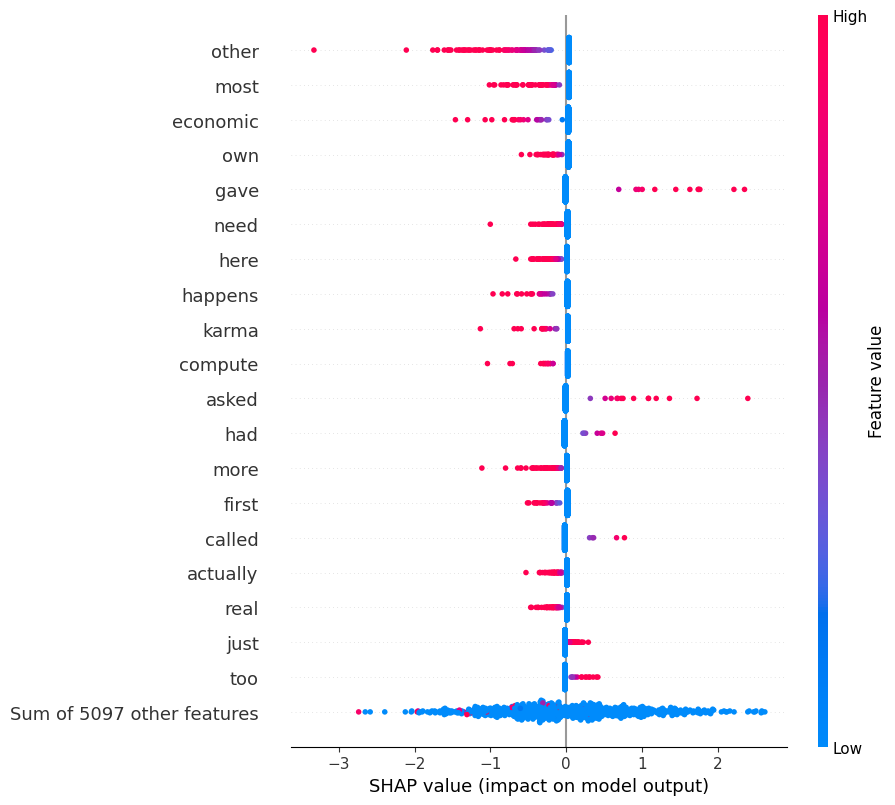

In [90]:
import shap

explainer = shap.LinearExplainer(
    model,
    X_train_tfidf,
    feature_names=vectorizer.get_feature_names_out()
)

shap_values_ambiguous = explainer(X_ambig)

shap.plots.beeswarm(shap_values_ambiguous, max_display=20)
